# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
|---|---|---|
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---
## Крок 0. Ваші дані та варіант

In [4]:
ПІБ = 'Михальчук Антон'
ГРУПА = 'ШІ-32'
ВАРІАНТ = 13

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ (1..30)'

In [5]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 13 · Михальчук Антон, ШІ-32, «Астро-ТВ»
Підприємство «Астро-ТВ» виготовляє телевізори. Одиниця виміру плану: шт./день.

                       Astro  Cosmo  Nova  Vega  ЗАПАС
Конвеєр A, год             1      5     3     0    937
Конвеєр Б, год             6      4     6     3   1390
Цех кінескопів, год        4      4     4     1    603
Цех корпусів, год          0      3     5     3   1120
Ділянка збирання, год      3      5     3     3   1334

                    Astro  Cosmo  Nova  Vega
Прибуток з одиниці     59     42    53    19

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Цех кінескопів, год
  ціна:   15.1 за одиницю
  обсяг:  до 646 одиниць


In [6]:
import matplotlib.pyplot as plt
try:
    import pulp
    ПУЛП = True
except ImportError:
    ПУЛП = False
    print('pulp не встановлено — скористайтеся scipy.optimize.linprog')
from scipy.optimize import linprog

pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

---
# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1
Заповніть у клітинці нижче:

* **змінні рішення** — що саме ви обираєте і в яких одиницях;
* **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
* **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
* **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280   (конвеєр A)`

**Відповідь 1.1 — символічна модель**

Змінні рішення: $x_1, x_2, x_3, x_4$ — обсяг випуску телевізорів Astro, Cosmo, Nova, Vega, шт./день.

Цільова функція (прибуток):
$$Z = 59x_1 + 42x_2 + 53x_3 + 19x_4 \to \max$$

Обмеження (витрата ресурсу не перевищує запасу):

$$
\begin{aligned}
1x_1 + 5x_2 + 3x_3 + 0x_4 &\le 937 &&\text{(конвеєр A, год)}\\
6x_1 + 4x_2 + 6x_3 + 3x_4 &\le 1390 &&\text{(конвеєр Б, год)}\\
4x_1 + 4x_2 + 4x_3 + 1x_4 &\le 603 &&\text{(цех кінескопів, год)}\\
0x_1 + 3x_2 + 5x_3 + 3x_4 &\le 1120 &&\text{(цех корпусів, год)}\\
3x_1 + 5x_2 + 3x_3 + 3x_4 &\le 1334 &&\text{(ділянка збирання, год)}
\end{aligned}
$$

Невід'ємність: $x_1, x_2, x_3, x_4 \ge 0$.


### Завдання 1.2 — питання на розуміння
Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?

**Відповідь 1.2:** Запас ресурсу — параметр, бо він заданий заздалегідь: конвеєри й цехи мають фіксований фонд годин на день, і директор його не обирає, а лише розподіляє між виробами.

Якби ресурс можна було отримувати безкоштовно в будь-якій кількості, модель втратила б зміст: прибуток можна було б нарощувати без кінця, просто збільшуючи запаси.

Якщо ж ресурс можна докупити за певною ціною, купувати варто лише тоді, коли додаткова одиниця ресурсу приносить більше прибутку, ніж коштує (за рівності — байдуже). І це вигідно не безмежно: що більше докуповуємо, то швидше вичерпуються інші ресурси, вони стають новим вузьким місцем, і подальші закупівлі вже не збільшують виробництва — гроші витрачаються на потужність, яку нема чим завантажити.


---
# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

### Завдання 2.1
Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.

In [7]:
# впишіть числа, які дав Excel
EXCEL_ПЛАН    = [69.83333333, 0, 0, 323.6666667]     # оптимальний випуск кожного виробу
EXCEL_ПРИБУТОК = 10269.83333


---
# Етап 3. Розв'язання в Python

### Завдання 3.1
Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [8]:
# linprog мінімізує, тому передаємо -c і беремо прибуток як -r.fun
r = linprog(-c, A_ub=A, b_ub=b, bounds=[(0, None)] * len(c), method='highs')
план = r.x
прибуток = -r.fun

print(pd.Series(план, index=вироби).round(3).to_string())
print('Прибуток: %.2f' % прибуток)


Astro     69.833
Cosmo      0.000
Nova       0.000
Vega     323.667
Прибуток: 10269.83


**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [9]:
assert план is not None and прибуток is not None, 'спершу розв’яжіть задачу'
assert abs(прибуток - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, прибуток))
assert np.allclose(np.array(план, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


---
# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

| Ресурс | Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Конвеєр A, год | 69.83 | 0 | 937 | ∞ | 867.17 |
| Конвеєр Б, год | 1390 | 2.833 | 1390 | 74.5 | 485.5 |
| Цех кінескопів, год | 603 | 10.5 | 603 | 323.67 | 49.67 |
| Цех корпусів, год | 971 | 0 | 1120 | ∞ | 149 |
| Ділянка збирання, год | 1180.5 | 0 | 1334 | ∞ | 153.5 |

**Які ресурси в дефіциті, а які в надлишку? Як ви це визначили?**

У дефіциті — конвеєр Б і цех кінескопів: їх витрачено повністю (кінцеве значення дорівнює правій частині), і саме вони обмежують прибуток. Тіньова ціна в них додатна: додаткова година цеху кінескопів збільшила б прибуток на 10.5, а година конвеєра Б — лише на 2.83, тож найцінніший ресурс — цех кінескопів. Конвеєр A, цех корпусів і ділянка збирання в надлишку: частина їхнього запасу не використана, тому ще одна година нічого не додасть, і тіньова ціна дорівнює 0.


### Завдання 4.2 — блок «Змінні»

| Виріб | Кінцеве значення | Зведена вартість | Цільовий коефіцієнт | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Astro | 69.83 | 0 | 59 | 17 | 6 |
| Cosmo | 0 | −11.33 | 42 | 11.33 | ∞ |
| Nova | 0 | −6 | 53 | 6 | ∞ |
| Vega | 323.67 | 0 | 19 | 8.5 | 4.25 |

*Надбудова Solver в Excel Online подає замість допустимих збільшення/зменшення межі коефіцієнта (Maximum / Minimum Objective Coefficient); збільшення = максимум − коефіцієнт, зменшення = коефіцієнт − мінімум.*

**У вашому варіанті принаймні один виріб не виробляється зовсім.**
Який саме, і на скільки мусив би зрости прибуток з його одиниці, щоб він увійшов у план?
Звідки ви взяли це число?

Не виробляються Cosmo і Nova. Щоб увійти в план, прибуток з одиниці мав би зрости: для Cosmo — на 11.33 (з 42 до 53.33), для Nova — на 6 (з 53 до 59). Це модуль зведеної вартості (Reduced Cost) зі звіту, і він же дорівнює допустимому збільшенню коефіцієнта.

Число можна перевірити через тіньові ціни: один Cosmo забирає 4 год конвеєра Б і 4 год цеху кінескопів, які в поточному плані «варті» 4·2.833 + 4·10.5 = 53.33 прибутку. Cosmo дає лише 42, тож кожна штука — це втрата 11.33. Для Nova: 6·2.833 + 4·10.5 = 59 проти 53, втрата 6. Вироби в плані (Astro, Vega) окуповують свої ресурси рівно: 6·2.833 + 4·10.5 = 59 і 3·2.833 + 1·10.5 = 19, тому їхня зведена вартість дорівнює 0.


---
# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1
Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [10]:
# найдорожчий ресурс за тіньовою ціною (зі звіту Excel: цех кінескопів, 10.5)
k = ресурси.index('Цех кінескопів, год')
тіньова_ціна_звіт = 10.5

def max_прибуток(b_new):
    r = linprog(-c, A_ub=A, b_ub=b_new, bounds=[(0, None)] * len(c), method='highs')
    return -r.fun

b_plus = b.copy()
b_plus[k] += 1                       # +1 година цеху кінескопів
приріст = max_прибуток(b_plus) - прибуток

print('Прибуток базовий:   %.4f' % прибуток)
print('Прибуток з +1 год:  %.4f' % max_прибуток(b_plus))
print('Приріст:            %.4f' % приріст)
print('Тіньова ціна (звіт): %.4f' % тіньова_ціна_звіт)


Прибуток базовий:   10269.8333
Прибуток з +1 год:  10280.3333
Приріст:            10.5000
Тіньова ціна (звіт): 10.5000


**Відповідь 5.1:** Найдорожчий за тіньовою ціною ресурс — цех кінескопів. Після збільшення його запасу на 1 год (603 → 604) прибуток зріс з 10269.83 до 10280.33, тобто на 10.5. Тіньова ціна зі звіту Excel — 10.5. Значення збігаються: прогноз зі звіту підтверджено експериментом.


### Завдання 5.2
Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

Тіньова ціна 10.5 тримається для перших 323 додаткових годин
Допустиме збільшення зі звіту Excel: 323.67


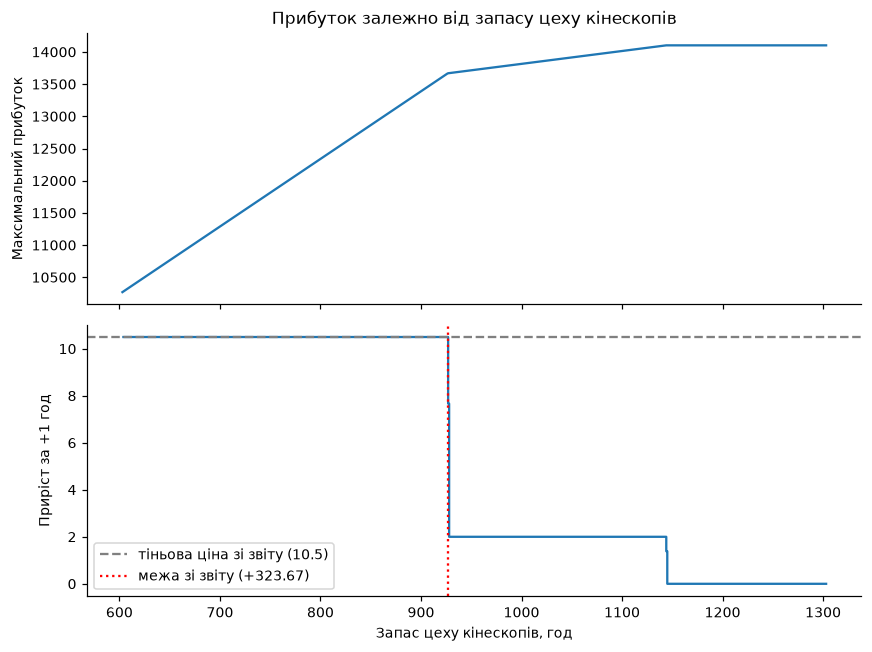

In [11]:
кроки = np.arange(0, 701)            # додаткові години цеху кінескопів: 0..700
прибутки = []
for t in кроки:
    b_new = b.copy()
    b_new[k] += t
    прибутки.append(max_прибуток(b_new))
прибутки = np.array(прибутки)
нахил = np.diff(прибутки)            # приріст за кожну наступну годину

межа = np.argmax(np.abs(нахил - тіньова_ціна_звіт) > 1e-6)   # перший крок, де нахил ≠ 10.5
print('Тіньова ціна 10.5 тримається для перших %d додаткових годин' % межа)
print('Допустиме збільшення зі звіту Excel: 323.67')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax1.plot(b[k] + кроки, прибутки)
ax1.set_ylabel('Максимальний прибуток')
ax1.set_title('Прибуток залежно від запасу цеху кінескопів')
ax2.step(b[k] + кроки[1:], нахил, where='post')
ax2.axhline(тіньова_ціна_звіт, ls='--', c='gray', label='тіньова ціна зі звіту (10.5)')
ax2.axvline(b[k] + 323.67, ls=':', c='red', label='межа зі звіту (+323.67)')
ax2.set_xlabel('Запас цеху кінескопів, год')
ax2.set_ylabel('Приріст за +1 год')
ax2.legend()
plt.tight_layout()
plt.show()


**Відповідь 5.2:** Тіньова ціна 10.5 тримається для перших 323 додаткових годин цеху кінескопів (приблизно до запасу 926.67 год). Межа збігається з допустимим збільшенням зі звіту Excel (+323.67). Після межі приріст падає не плавно, а стрибком: спершу до 2 за годину, а приблизно після +541 год — до 0, тобто подальші години цеху вже не дають прибутку.


---
# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1
Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

Ціна пропозиції: 15.1, тіньова ціна: 10.5
Найкращий обсяг закупівлі: 0 год, чистий виграш: 0.00
  купити   1 год -> чистий результат     -4.60
  купити 100 год -> чистий результат   -460.00
  купити 323 год -> чистий результат  -1485.80
  купити 646 год -> чистий результат  -5922.05


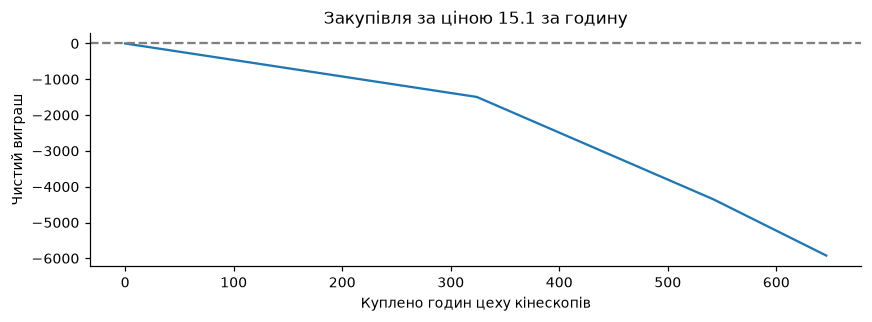

In [15]:
ціна = V['ціна_пропозиції']          # 15.1
обсяг = V['обсяг_пропозиції']        # 646
k_оф = V['ресурс_пропозиції']        # цех кінескопів

обсяги = np.arange(0, обсяг + 1)
чистий_виграш = []
for q in обсяги:
    b_new = b.copy()
    b_new[k_оф] += q
    чистий_виграш.append(max_прибуток(b_new) - ціна * q - прибуток)
чистий_виграш = np.array(чистий_виграш)

q_best = обсяги[np.argmax(чистий_виграш)]
print('Ціна пропозиції: %.1f, тіньова ціна: %.1f' % (ціна, тіньова_ціна_звіт))
print('Найкращий обсяг закупівлі: %d год, чистий виграш: %.2f' % (q_best, чистий_виграш.max()))
for q in [1, 100, 323, 646]:
    print('  купити %3d год -> чистий результат %9.2f' % (q, чистий_виграш[q]))

plt.figure(figsize=(8, 3))
plt.plot(обсяги, чистий_виграш)
plt.axhline(0, c='gray', ls='--')
plt.xlabel('Куплено годин цеху кінескопів')
plt.ylabel('Чистий виграш')
plt.title('Закупівля за ціною %.1f за годину' % ціна)
plt.tight_layout()
plt.show()


**Відповідь 6.1:**

* Брати чи ні і чому: **не брати**. Постачальник просить 15.1 за годину цеху кінескопів, а тіньова ціна цього ресурсу — лише 10.5: навіть перша додаткова година приносить менше прибутку, ніж коштує.
* Скільки одиниць має сенс купити і чому не більше: **0**. Тіньова ціна 10.5 — це найбільший можливий приріст (далі він падає до 2, а потім до 0), тож кожна наступна година ще збитковіша за першу.
* Очікуваний виграш: **0** (без закупівлі); будь-яка закупівля дає збиток — щонайменше 15.1 − 10.5 = 4.6 на кожній з перших 323 годин.
* Перевірка прямим розв'язанням дала: найкращий обсяг — 0 год; купівля 1 год дає −4.60, 100 год — −460.00, 323 год — −1485.80, увесь обсяг 646 год — −5922.05.


---
# Етап 7. Перевірка розв'язку

### Завдання 7.1
Порахуйте дві величини:

* скільки виробів мають **ненульовий** випуск;
* скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [13]:
eps = 1e-6
ненульових = int(np.sum(план > eps))
звязних = int(np.sum(np.abs(A @ план - b) < eps))   # витрата = запас


In [14]:
assert ненульових is not None and звязних is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (ненульових, звязних))
assert ненульових == звязних, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

AssertionError: спершу порахуйте

**Відповідь 7.1:** Ненульовий випуск мають 2 вироби (Astro і Vega), зв'язних обмежень теж 2 (конвеєр Б і цех кінескопів) — числа збіглися. Зв'язне обмеження — це рівняння (витрата дорівнює запасу), тож дві ненульові змінні однозначно визначаються двома рівняннями, і оптимальний план єдиний. Якби ненульових змінних було більше, ніж зв'язних обмежень (наприклад, 3 невідомі й 2 рівняння), система мала б безліч розв'язків — оптимальний план не був би визначений однозначно.


---
# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1
Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [ ]:
def перевірка(x):
    допустимий = bool(np.all(A @ x <= b + 1e-9) and np.all(x >= 0))
    return допустимий, float(c @ x)

округлений = np.round(план)

r_int = linprog(-c, A_ub=A, b_ub=b, bounds=[(0, None)] * len(c),
                integrality=np.ones(len(c)), method='highs')
цілий = r_int.x

рядки = []
for назва, x in [('без умови цілочисельності', план),
                 ('округлений', округлений),
                 ('цілочисельний оптимум', цілий)]:
    доп, приб = перевірка(x)
    рядки.append([назва, np.round(x, 2).tolist(), round(приб, 2), 'так' if доп else 'НІ'])
print(pd.DataFrame(рядки, columns=['Варіант', 'План ' + str(вироби), 'Прибуток', 'Допустимий?']).to_string(index=False))

print('\nПорушення округленого плану (витрата − запас > 0):')
надлишок = A @ округлений - b
for рес, d in zip(ресурси, надлишок):
    if d > 1e-9:
        print('  %s: перевищено на %.0f' % (рес, d))


**Відповідь 8.1:**

| Варіант | План (Astro, Cosmo, Nova, Vega) | Прибуток | Допустимий? |
|---|---|---|---|
| без умови цілочисельності | 69.83, 0, 0, 323.67 | 10269.83 | так |
| округлений | 70, 0, 0, 324 | 10286.00 | ні: конвеєр Б перевищено на 2 год, цех кінескопів — на 1 год |
| цілочисельний оптимум | 70, 0, 0, 323 | 10267.00 | так |

**Висновок:** округлювати навмання не можна. Звичайне округлення дало план, який порушує обидва дефіцитні обмеження. Це видно навіть без перевірки: його прибуток (10286) більший за дробовий оптимум (10269.83), а дробова задача має менше обмежень, ніж цілочисельна, тож її оптимум — верхня межа для будь-якого допустимого цілого плану. Округлення обох значень униз (69 і 323) допустиме, але не найкраще. Справжній цілочисельний оптимум — округлити вниз лише Vega: 70 Astro і 323 Vega, прибуток 10267, лише на 2.83 менше за дробовий. Тому цілий план треба шукати розв'язанням задачі з умовою цілочисельності, а не округленням.


---
# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1
Сформуйте власні дані:

* **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
* **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
* **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
* **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [ ]:
постачальники = ['Миколаїв', 'Харків', 'Апостолове']    # М, Х, А (на «И» міст немає)
споживачі     = ['Арциз', 'Ніжин', 'Тернопіль', 'Одеса']  # А, Н, Т, О
# відстані автошляхами, км (OpenStreetMap / OSRM, 04.10.2026)
D = np.array([[267, 527, 697, 132],
              [817, 442, 939, 683],
              [452, 508, 720, 318]], float)
запас = [40, 35, 25]
попит = [20, 30, 25, 25]

assert len(постачальники) == 3 and len(споживачі) == 4, 'потрібно 3 постачальники і 4 споживачі'
assert D.shape == (3, 4), 'матриця відстаней має бути 3 x 4'
assert sum(запас) == sum(попит), 'сумарний запас має дорівнювати сумарному попиту'
pd.DataFrame(D, index=постачальники, columns=споживачі)


---
# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1
Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [ ]:
# розв'язок 1 — PuLP (CBC)
m, n = D.shape
prob = pulp.LpProblem('transport', pulp.LpMinimize)
x = {(i, j): pulp.LpVariable(f'x_{i}_{j}', lowBound=0) for i in range(m) for j in range(n)}
prob += pulp.lpSum(D[i, j] * x[i, j] for i in range(m) for j in range(n))
for i in range(m):
    prob += (pulp.lpSum(x[i, j] for j in range(n)) == запас[i], f'запас_{i}')
for j in range(n):
    prob += (pulp.lpSum(x[i, j] for i in range(m)) == попит[j], f'попит_{j}')
prob.solve(pulp.PULP_CBC_CMD(msg=0))

X1 = np.array([[x[i, j].value() for j in range(n)] for i in range(m)])
u1 = np.array([prob.constraints[f'запас_{i}'].pi for i in range(m)])   # тіньові ціни постачальників
v1 = np.array([prob.constraints[f'попит_{j}'].pi for j in range(n)])   # тіньові ціни споживачів
вартість1 = pulp.value(prob.objective)

print('PuLP (CBC): сумарна вартість = %.0f' % вартість1)
print(pd.DataFrame(X1, index=постачальники, columns=споживачі).to_string())
print('Тіньові ціни постачальників:', dict(zip(постачальники, u1.round(2).tolist())))
print('Тіньові ціни споживачів:   ', dict(zip(споживачі, v1.round(2).tolist())))


In [ ]:
# розв'язок 2 — scipy.optimize.linprog (HiGHS); 12 змінних x_ij розгорнуто в один рядок
A_eq = np.zeros((m + n, m * n))
for i in range(m):
    A_eq[i, i * n:(i + 1) * n] = 1      # рядок постачальника i: x_i0 + ... + x_i3
for j in range(n):
    A_eq[m + j, j::n] = 1               # рядок споживача j: x_0j + x_1j + x_2j
b_eq = np.array(запас + попит, float)

r2 = linprog(D.ravel(), A_eq=A_eq, b_eq=b_eq, bounds=[(0, None)] * (m * n), method='highs')
X2 = r2.x.reshape(m, n)
u2, v2 = r2.eqlin.marginals[:m], r2.eqlin.marginals[m:]
вартість2 = r2.fun

print('linprog (HiGHS): сумарна вартість = %.0f' % вартість2)
print(pd.DataFrame(X2, index=постачальники, columns=споживачі).to_string())
print('Тіньові ціни постачальників:', dict(zip(постачальники, u2.round(2).tolist())))
print('Тіньові ціни споживачів:   ', dict(zip(споживачі, v2.round(2).tolist())))


### Завдання 10.2 — головне питання цієї частини
Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [ ]:
різниця_пост = u1 - u2
різниця_спож = v1 - v2
print('Вартість: PuLP = %.0f, linprog = %.0f' % (вартість1, вартість2))
print('PuLP − linprog, постачальники:', dict(zip(постачальники, різниця_пост.round(2).tolist())))
print('PuLP − linprog, споживачі:    ', dict(zip(споживачі, різниця_спож.round(2).tolist())))

# на кожному маршруті з ненульовим перевезенням: u_i + v_j = d_ij в обох розв'язувачах
for i in range(m):
    for j in range(n):
        if X1[i, j] > 1e-9:
            print('  %s → %s: d = %.0f | PuLP u+v = %.0f | linprog u+v = %.0f'
                  % (постачальники[i], споживачі[j], D[i, j], u1[i] + v1[j], u2[i] + v2[j]))


**Відповідь 10.2:**

* Вартість у двох розв'язувачів: однакова — 41920 од.·км, і план перевезень теж однаковий.
* Тіньові ціни збіглися чи ні: ні, набори різні (наприклад, Миколаїв: 132 у PuLP і 0 у linprog).
* Яку закономірність ви побачили в різниці: різниця постійна — у всіх постачальників PuLP дає на 132 більше, у всіх споживачів на 132 менше. На кожному маршруті з ненульовим перевезенням в обох розв'язувачах виконується $u_i + v_j = d_{ij}$, тож зсув «+k постачальникам, −k споживачам» нічого не змінює. Причина — одне з 7 обмежень зайве: якщо постачальники вивезли все, а троє споживачів отримали свій попит, четвертий отримає залишок автоматично. Тому одну тіньову ціну можна обрати довільно, і кожен розв'язувач фіксує її по-своєму (linprog — Миколаїв = 0, PuLP — Одеса = 0).
* Що це означає для того, хто збирається ухвалювати рішення за цим звітом: окрему тіньову ціну пункту не можна читати як «ціну» його запасу чи попиту, як у частині 1 — вона залежить від того, який розв'язувач використано. Сенс мають лише суми та різниці ($u_i + v_j$, різниця між двома постачальниками чи двома споживачами), однакові для будь-якого розв'язувача.


---
# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1
Порахуйте для транспортної задачі те саме, що на етапі 7:

* кількість **ненульових перевезень**;
* кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [ ]:
# ВАШ КОД


**Відповідь 11.1:**

* Ненульових перевезень:
* Зв'язних обмежень:
* Чому в транспортній задачі зв'язними виявляються **всі** обмеження:
* На скільки ненульових перевезень менше і чому саме на стільки:


### Завдання 11.2 — візуалізація
Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

In [ ]:
# ВАШ КОД


**Висновок:** *(одне речення про те, що видно на теплових картах)*

---
# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [ ]:
ІНСТРУМЕНТИ_ШІ = ''     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі':          '',
    'етап 2, побудова моделі в Excel':      '',
    'етап 3, код на Python':                '',
    'етапи 4–5, читання та перевірка звіту': '',
    'етап 6, рішення про закупівлю':        '',
    'етапи 7–8, перевірка та цілочисельність': '',
    'етапи 9–11, транспортна задача':       '',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно.
ЩО_ПЕРЕВІРЕНО = ''

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-яке число
# цієї роботи та внести зміни в модель на вимогу під час захисту.
ПІДТВЕРДЖУЮ = False

In [ ]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

---
# Крок 13. Фінальна самоперевірка

In [ ]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': ненульових == звязних,
    'дані транспортної задачі введено':   len(постачальники) == 3 and len(споживачі) == 4,
    'баланс запасів і попиту':            sum(запас) == sum(попит),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')